# Klasifikasi Aktivitas Login Normal dan Mencurigakan
Notebook ini melakukan klasifikasi aktivitas login normal dan mencurigakan berdasarkan pola waktu, lokasi, dan perangkat menggunakan Random Forest.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 3. Membaca Dataset

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/meimaharani603/Cyber-Login-Classification/main/auth_authz_failures_dataset.csv"

df = pd.read_csv(url)

df.head()

,timestamp,user_id,username,ip_address,device_type,os_type,browser,location,login_method,success,...,token_expired,session_duration,password_age_days,role,privilege_level,suspicious_activity,threat_level,blocked,error_code,system_component
0,2025-07-23 00:10:24,6a214818-e78e-47fc-a728-226c70b18e37,jonesdanielle,148.6.34.231,Tablet,Windows,Edge,"Lake Robertbury, Bhutan",Password,False,...,True,3167,198,Guest,5,True,10,False,ERR003,API Gateway
1,2025-12-09 12:43:10,6ad7f4f8-3b0b-45c8-b6aa-2cf6a10b2040,michaelsanchez,134.106.53.46,PC,MacOS,Edge,"Jeffersonville, India",MFA,True,...,True,3360,146,Admin,2,True,5,False,NaN,Frontend
2,2025-04-10 04:15:24,ec4aa120-d196-45af-98ca-4a13ec08d354,martinezcrystal,164.233.90.226,PC,Linux,Firefox,"Michaelhaven, French Polynesia",API Key,True,...,False,1836,356,Admin,2,False,10,False,NaN,API Gateway
3,2026-02-13 02:22:46,71041fa0-b11c-4df8-ace3-59a60b13d613,michaelhardin,205.62.126.123,PC,Windows,Chrome,"Port Seth, Gambia",API Key,True,...,False,46,224,Admin,2,True,3,False,NaN,Frontend
4,2025-02-15 12:41:34,130c32b7-28e7-4d6c-99e0-2e17a439550e,vincentjoshua,157.225.10.229,PC,iOS,Safari,"Georgeview, Central African Republic",MFA,True,...,True,2039,215,Guest,3,False,9,False,NaN,Frontend


## 4. Informasi Dataset

In [3]:
print(df.shape)
df.info()

(50000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            50000 non-null  object
 1   user_id              50000 non-null  object
 2   username             50000 non-null  object
 3   ip_address           50000 non-null  object
 4   device_type          50000 non-null  object
 5   os_type              50000 non-null  object
 6   browser              50000 non-null  object
 7   location             50000 non-null  object
 8   login_method         50000 non-null  object
 9   success              50000 non-null  bool  
 10  failure_reason       18636 non-null  object
 11  auth_type            50000 non-null  object
 12  account_status       50000 non-null  object
 13  failed_attempts      50000 non-null  int64 
 14  mfa_enabled          50000 non-null  bool  
 15  token_expired        50000 non-null  bool

## 5. Missing Value

In [4]:
df.isnull().sum()

,0
timestamp,0
user_id,0
username,0
ip_address,0
device_type,0
os_type,0
browser,0
location,0
login_method,0
success,0


### Analisis
Tahap ini digunakan untuk memastikan tidak terdapat nilai yang hilang (missing value) sehingga data siap diproses.

## 6. Distribusi Target

In [5]:
df["suspicious_activity"].value_counts()

,count
suspicious_activity,
False,25169
True,24831


### Analisis
Distribusi kelas digunakan untuk mengetahui apakah jumlah data normal dan mencurigakan seimbang atau tidak.

## 7. Feature Engineering

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df.head()

,timestamp,user_id,username,ip_address,device_type,os_type,browser,location,login_method,success,...,session_duration,password_age_days,role,privilege_level,suspicious_activity,threat_level,blocked,error_code,system_component,hour
0,2025-07-23 00:10:24,6a214818-e78e-47fc-a728-226c70b18e37,jonesdanielle,148.6.34.231,Tablet,Windows,Edge,"Lake Robertbury, Bhutan",Password,False,...,3167,198,Guest,5,True,10,False,ERR003,API Gateway,0
1,2025-12-09 12:43:10,6ad7f4f8-3b0b-45c8-b6aa-2cf6a10b2040,michaelsanchez,134.106.53.46,PC,MacOS,Edge,"Jeffersonville, India",MFA,True,...,3360,146,Admin,2,True,5,False,NaN,Frontend,12
2,2025-04-10 04:15:24,ec4aa120-d196-45af-98ca-4a13ec08d354,martinezcrystal,164.233.90.226,PC,Linux,Firefox,"Michaelhaven, French Polynesia",API Key,True,...,1836,356,Admin,2,False,10,False,NaN,API Gateway,4
3,2026-02-13 02:22:46,71041fa0-b11c-4df8-ace3-59a60b13d613,michaelhardin,205.62.126.123,PC,Windows,Chrome,"Port Seth, Gambia",API Key,True,...,46,224,Admin,2,True,3,False,NaN,Frontend,2
4,2025-02-15 12:41:34,130c32b7-28e7-4d6c-99e0-2e17a439550e,vincentjoshua,157.225.10.229,PC,iOS,Safari,"Georgeview, Central African Republic",MFA,True,...,2039,215,Guest,3,False,9,False,NaN,Frontend,12


### Analisis
Kolom timestamp diubah menjadi jam login sehingga model dapat mempelajari pola waktu aktivitas pengguna.

## 8. Pemilihan Fitur

In [7]:
features = [
    "hour",
    "location",
    "device_type",
    "os_type",
    "browser",
    "login_method",
    "failed_attempts",
    "account_status",
    "mfa_enabled",
    "role",
    "privilege_level"
]

target = "suspicious_activity"


## 9. Encoding

In [8]:
encoder = LabelEncoder()

for col in features:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col].astype(str))

df[target] = encoder.fit_transform(df[target].astype(str))


### Analisis
Seluruh data kategorikal diubah menjadi numerik menggunakan LabelEncoder agar dapat diproses oleh Random Forest.

## 10. Split Data

In [9]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## 11. Training Model

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

### Analisis
Model Random Forest dibangun menggunakan data latih untuk mempelajari pola aktivitas login.

## 12. Prediksi

In [11]:
y_pred = model.predict(X_test)

## 13. Evaluasi

In [12]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Accuracy : 0.4981

Classification Report

              precision    recall  f1-score   support

           0       0.50      0.53      0.52      5038
           1       0.49      0.46      0.48      4962

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



### Analisis
Accuracy menunjukkan tingkat ketepatan model, sedangkan Precision, Recall, dan F1-Score memberikan evaluasi kemampuan model dalam mendeteksi aktivitas login mencurigakan.

## 14. Confusion Matrix

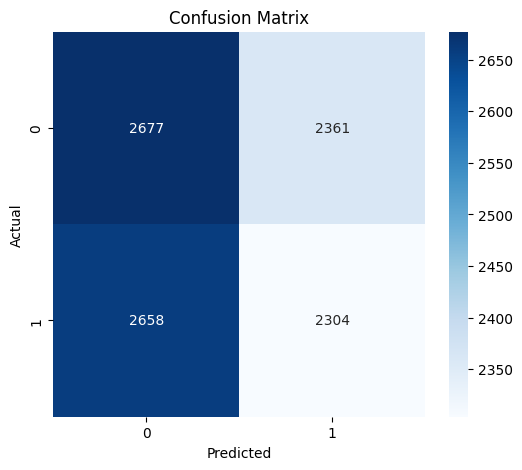

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### Analisis
Confusion Matrix menunjukkan jumlah prediksi benar (True Positive dan True Negative) serta kesalahan prediksi (False Positive dan False Negative). Dalam keamanan siber, False Negative menjadi perhatian utama karena aktivitas berbahaya dapat lolos dari deteksi.

## 15. Feature Importance

,Feature,Importance
1,location,0.257521
0,hour,0.163571
6,failed_attempts,0.119970
10,privilege_level,0.075303
4,browser,0.074700
3,os_type,0.072212
5,login_method,0.063464
9,role,0.049720
2,device_type,0.047712
7,account_status,0.045242


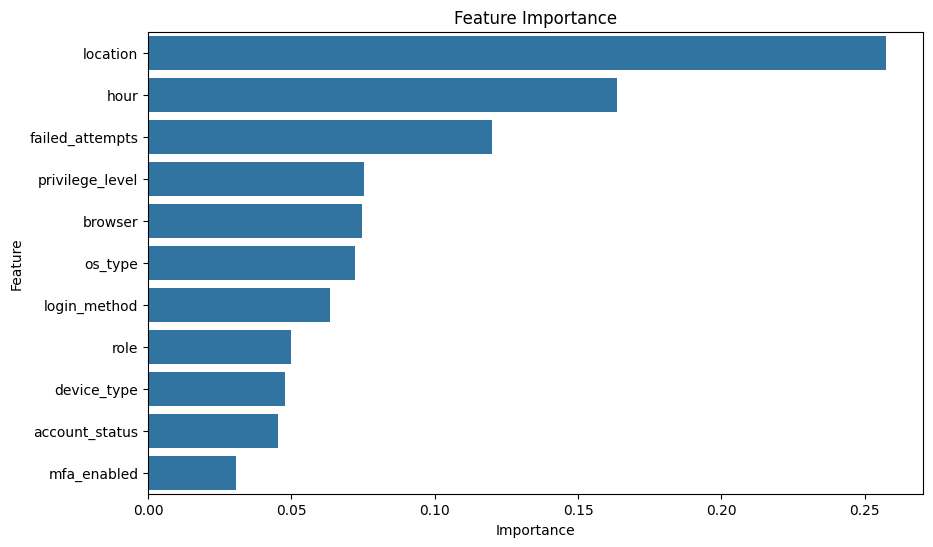

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()


## Kesimpulan

Model Random Forest digunakan untuk mengklasifikasikan aktivitas login menjadi kategori normal atau mencurigakan berdasarkan pola waktu, lokasi, perangkat, serta atribut pendukung lainnya. Evaluasi dilakukan menggunakan Accuracy, Classification Report, Confusion Matrix, dan Feature Importance untuk mengetahui performa model sekaligus faktor-faktor yang paling memengaruhi hasil klasifikasi.
